In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import joblib

In [7]:
df=pd.read_csv("C:\\Users\\ASUS\\Downloads\\eda_data.csv.zip")

In [8]:
df.head()

,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,...,age,python_yn,R_yn,spark,aws,excel,job_simp,seniority,desc_len,num_comp
0,0,Data Scientist,$53K-$91K (Glassdoor est.),"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,Tecolote Research\n3.8,"Albuquerque, NM","Goleta, CA",501 to 1000 employees,1973,...,47,1,0,0,0,1,data scientist,na,2536,0
1,1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),What You Will Do:\n\nI. General Summary\n\nThe...,3.4,University of Maryland Medical System\n3.4,"Linthicum, MD","Baltimore, MD",10000+ employees,1984,...,36,1,0,0,0,0,data scientist,na,4783,0
2,2,Data Scientist,$80K-$90K (Glassdoor est.),"KnowBe4, Inc. is a high growth information sec...",4.8,KnowBe4\n4.8,"Clearwater, FL","Clearwater, FL",501 to 1000 employees,2010,...,10,1,0,1,0,1,data scientist,na,3461,0
3,3,Data Scientist,$56K-$97K (Glassdoor est.),*Organization and Job ID**\nJob ID: 310709\n\n...,3.8,PNNL\n3.8,"Richland, WA","Richland, WA",1001 to 5000 employees,1965,...,55,1,0,0,0,0,data scientist,na,3883,3
4,4,Data Scientist,$86K-$143K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,...,22,1,0,0,0,1,data scientist,na,2728,3


In [9]:
# Dataset information
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 742 entries, 0 to 741
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         742 non-null    int64  
 1   Job Title          742 non-null    str    
 2   Salary Estimate    742 non-null    str    
 3   Job Description    742 non-null    str    
 4   Rating             742 non-null    float64
 5   Company Name       742 non-null    str    
 6   Location           742 non-null    str    
 7   Headquarters       742 non-null    str    
 8   Size               742 non-null    str    
 9   Founded            742 non-null    int64  
 10  Type of ownership  742 non-null    str    
 11  Industry           742 non-null    str    
 12  Sector             742 non-null    str    
 13  Revenue            742 non-null    str    
 14  Competitors        742 non-null    str    
 15  hourly             742 non-null    int64  
 16  employer_provided  742 non-null    in

In [10]:
# Missing values
print(df.isnull().sum())

Unnamed: 0           0
Job Title            0
Salary Estimate      0
Job Description      0
Rating               0
Company Name         0
Location             0
Headquarters         0
Size                 0
Founded              0
Type of ownership    0
Industry             0
Sector               0
Revenue              0
Competitors          0
hourly               0
employer_provided    0
min_salary           0
max_salary           0
avg_salary           0
company_txt          0
job_state            0
same_state           0
age                  0
python_yn            0
R_yn                 0
spark                0
aws                  0
excel                0
job_simp             0
seniority            0
desc_len             0
num_comp             0
dtype: int64


In [11]:
# Statistical summary
df.describe(include='all')

,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,...,age,python_yn,R_yn,spark,aws,excel,job_simp,seniority,desc_len,num_comp
count,742.000000,742,742,742,742.000000,742,742,742,742,742.000000,...,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742,742,742.000000,742.000000
unique,NaN,264,416,463,NaN,343,200,198,9,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,7,3,NaN,NaN
top,NaN,Data Scientist,$86K-$143K (Glassdoor est.),Under direct supervision of the Director of Da...,NaN,Takeda Pharmaceuticals\n3.7,"New York, NY","New York, NY",1001 to 5000 employees,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,data scientist,na,NaN,NaN
freq,NaN,131,6,4,NaN,14,55,52,150,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,279,520,NaN,NaN
mean,370.500000,NaN,NaN,NaN,3.618868,NaN,NaN,NaN,NaN,1837.154987,...,46.591644,0.528302,0.002695,0.225067,0.237197,0.522911,NaN,NaN,3869.545822,1.053908
std,214.341239,NaN,NaN,NaN,0.801210,NaN,NaN,NaN,NaN,497.183763,...,53.778815,0.499535,0.051882,0.417908,0.425651,0.499812,NaN,NaN,1521.495868,1.384239
min,0.000000,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN,NaN,-1.000000,...,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,407.000000,0.000000
25%,185.250000,NaN,NaN,NaN,3.300000,NaN,NaN,NaN,NaN,1939.000000,...,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,2801.000000,0.000000
50%,370.500000,NaN,NaN,NaN,3.700000,NaN,NaN,NaN,NaN,1988.000000,...,24.000000,1.000000,0.000000,0.000000,0.000000,1.000000,NaN,NaN,3731.000000,0.000000
75%,555.750000,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,2007.000000,...,59.000000,1.000000,0.000000,0.000000,0.000000,1.000000,NaN,NaN,4740.000000,3.000000


In [12]:
# Define target and features
target = "num_comp"
X = df.drop(columns=[target])
y = df[target]
# Identifying the  categorical and numeric columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical Columns:", categorical_cols)
print("Numeric Columns:", numeric_cols)

Categorical Columns: ['Job Title', 'Salary Estimate', 'Job Description', 'Company Name', 'Location', 'Headquarters', 'Size', 'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors', 'company_txt', 'job_state', 'job_simp', 'seniority']
Numeric Columns: ['Unnamed: 0', 'Rating', 'Founded', 'hourly', 'employer_provided', 'min_salary', 'max_salary', 'avg_salary', 'same_state', 'age', 'python_yn', 'R_yn', 'spark', 'aws', 'excel', 'desc_len']


C:\Users\ASUS\AppData\Local\Temp\ipykernel_25288\4114979901.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns.tolist()


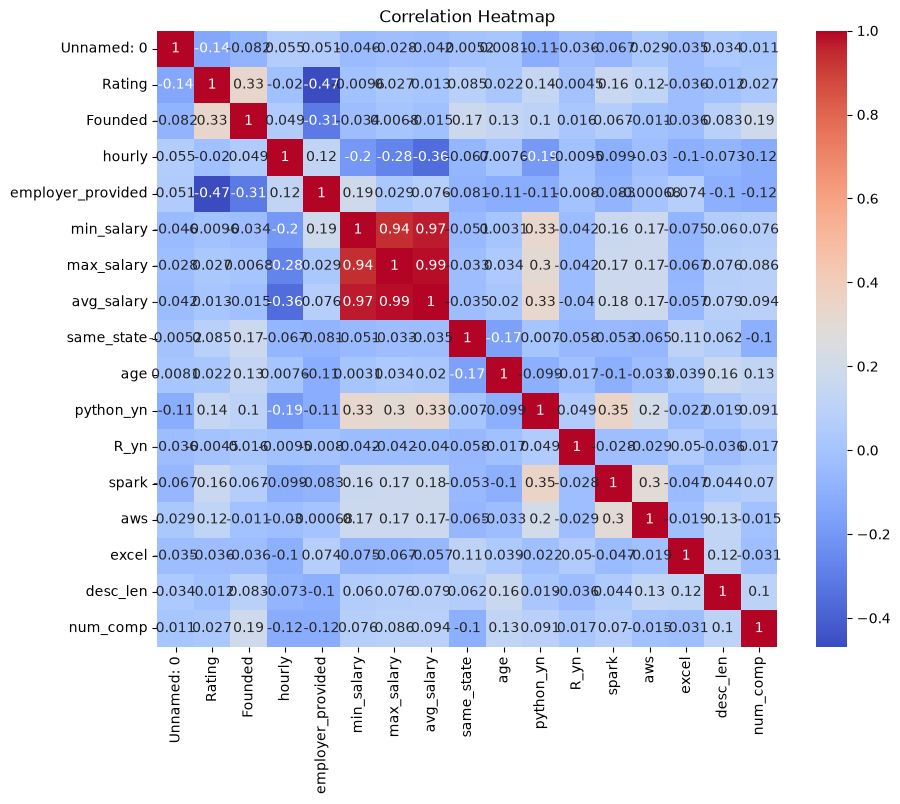

In [13]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [14]:
# Single feature model
X_single = df[['Unnamed: 0']]
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split( X_single, y, test_size=0.2, random_state=42)
single_model = LinearRegression()
single_model.fit(X_train_s, y_train_s)
y_pred_s = single_model.predict(X_test_s)

rmse_single = np.sqrt(mean_squared_error(y_test_s, y_pred_s))
r2_single = r2_score(y_test_s, y_pred_s)

print("Single Feature RMSE:", rmse_single)
print("Single Feature R2 Score:", r2_single)

Single Feature RMSE: 1.388933347704941
Single Feature R2 Score: -0.012499878978452283


In [16]:
# Preprocessing
numeric_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))])
categorical_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])
preprocessor = ColumnTransformer(
    transformers=[ ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols) ])
# Train-test split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)
# Create pipeline
multi_model = Pipeline(steps=[('preprocessor', preprocessor),('model', LinearRegression())])
# Train model
multi_model.fit(X_train, y_train)
# Predictions
y_pred = multi_model.predict(X_test)
# Evaluation
rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred))
r2_multi = r2_score(y_test, y_pred)
print("Multiple Regression RMSE:", rmse_multi)
print("Multiple Regression R2 Score:", r2_multi)

Multiple Regression RMSE: 0.1832692386852618
Multiple Regression R2 Score: 0.9823716639469134


               Model      RMSE  R2 Score
0     Single Feature  1.388933 -0.012500
1  Multiple Features  0.183269  0.982372


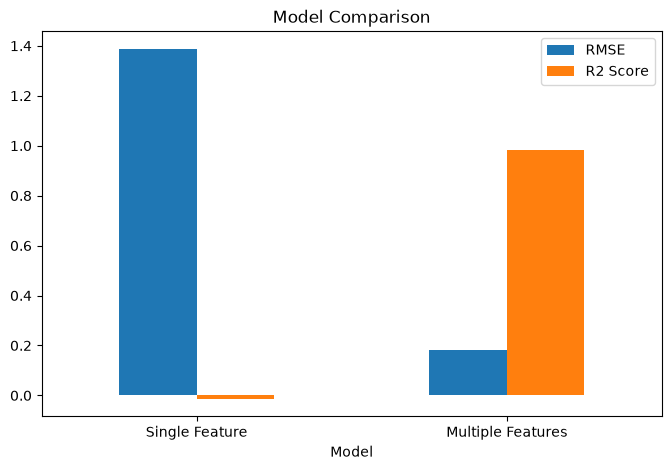

In [17]:
# Compare models
comparison = pd.DataFrame({'Model': ['Single Feature', 'Multiple Features'],
    'RMSE': [rmse_single, rmse_multi],
    'R2 Score': [r2_single, r2_multi]})

print(comparison)

# Bar plot comparison
comparison.plot(x='Model', y=['RMSE', 'R2 Score'], kind='bar', figsize=(8,5))
plt.title("Model Comparison")
plt.xticks(rotation=0)
plt.show()

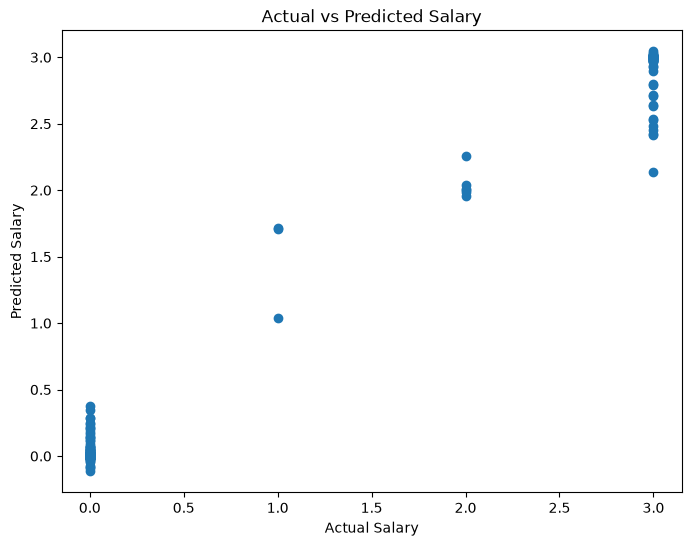

In [18]:
# Actual vs Predicted
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.show()

In [19]:
# Save best model
best_model = multi_model if r2_multi >= r2_single else single_model

joblib.dump(best_model, "best_salary_prediction_model.pkl")

print("Best model saved successfully!")

Best model saved successfully!


In [21]:

# Select best model
if r2_multi > r2_single:
    best_model = multi_model
    selected_model = "Multiple Linear Regression"
    reason = "Selected because it has higher R² score and better prediction accuracy."
else:
    best_model = single_model
    selected_model = "Single Feature Linear Regression"
    reason = "Selected because it performs better with lower prediction error."

print("Selected Model:", selected_model)
print("Reason:", reason)

# Save best model
joblib.dump(best_model, "best_salary_prediction_model.pkl")

print("Best model saved successfully!")

Selected Model: Multiple Linear Regression
Reason: Selected because it has higher R² score and better prediction accuracy.
Best model saved successfully!


In [22]:
# Example predictions
print("Example Predictions:")
print(y_pred[:5])

Example Predictions:
[0.04844907 0.01530403 3.00326393 0.02089642 2.01186641]
